In [2]:
# Install required packages
!pip install osmnx geopandas folium mapclassify -q
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("osmnx version:", ox.__version__)
print("All packages ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.4 MB/s eta 0:00:00
osmnx version: 2.1.0
All packages ready


In [3]:
place = "Ahmedabad, Gujarat, India"

print("Downloading buildings...")
buildings = ox.features_from_place(place, tags={"building": True})
buildings = buildings[buildings.geometry.geom_type
                      .isin(['Polygon','MultiPolygon'])]
print(f"Buildings: {len(buildings)}")

print("Downloading street network...")
G = ox.graph_from_place(place, network_type="drive")
streets = ox.graph_to_gdfs(G, nodes=False)
print(f"Streets: {len(streets)}")

print("Downloading green spaces...")
green = ox.features_from_place(place, tags={
    "leisure": ["park","garden"],
    "landuse": ["grass","forest","recreation_ground"],
    "natural": ["wood","scrub"]})
print(f"Green spaces: {len(green)}")

print("Downloading water bodies...")
water = ox.features_from_place(place, tags={
    "natural": "water",
    "waterway": True})
print(f"Water bodies: {len(water)}")

print("All OSM data downloaded successfully")

Buildings: 105303
Streets: 162949
Green spaces: 550
Water bodies: 1976
All OSM data downloaded successfully


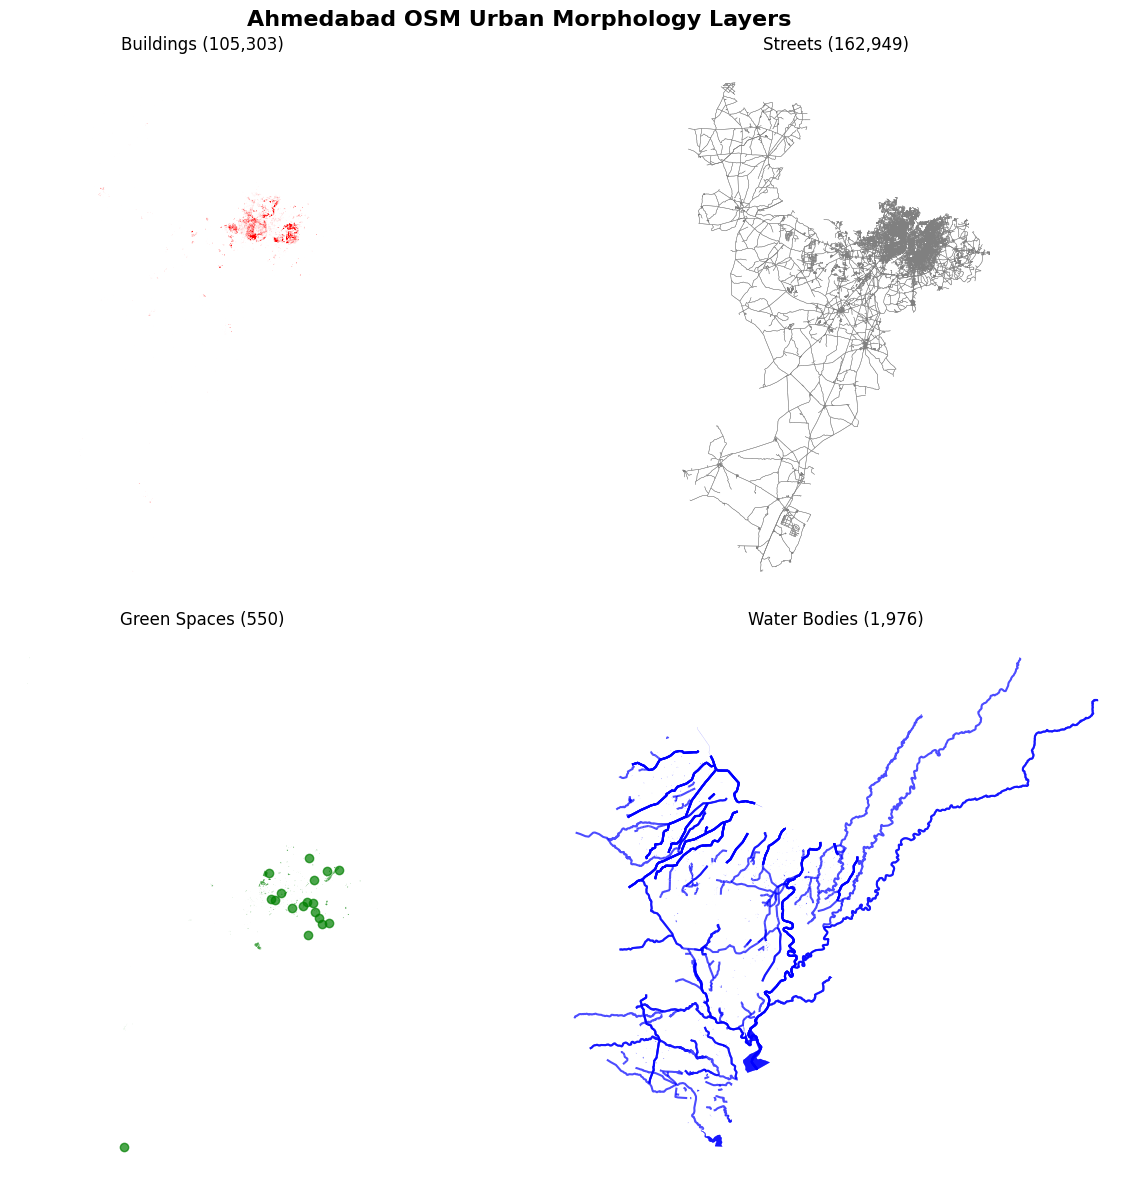

OSM map saved as AMD_OSM_layers.png


In [4]:
# Quick visual check of all layers
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

buildings.plot(ax=axes[0,0], color='red', alpha=0.5)
axes[0,0].set_title('Buildings (105,303)')
axes[0,0].axis('off')

streets.plot(ax=axes[0,1], color='gray', linewidth=0.3)
axes[0,1].set_title('Streets (162,949)')
axes[0,1].axis('off')

green.plot(ax=axes[1,0], color='green', alpha=0.7)
axes[1,0].set_title('Green Spaces (550)')
axes[1,0].axis('off')

water.plot(ax=axes[1,1], color='blue', alpha=0.7)
axes[1,1].set_title('Water Bodies (1,976)')
axes[1,1].axis('off')

plt.suptitle('Ahmedabad OSM Urban Morphology Layers',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('AMD_OSM_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print("OSM map saved as AMD_OSM_layers.png")

In [21]:
import geopandas as gpd

# Files are in root / not /content/
gdf = gpd.read_file('/REPROJECTEDSHAPEFILEWARDAHMEDABAD.shp')
gdf_wgs84 = gdf.to_crs("EPSG:4326")
city_boundary = gdf_wgs84.dissolve()
city_boundary['geometry'] = city_boundary.geometry.simplify(0.001)

print("Shapefile loaded successfully")
print("CRS:", city_boundary.crs)
print("Bounds:", city_boundary.total_bounds)

Shapefile loaded successfully
CRS: EPSG:4326
Bounds: [72.4498    22.9139487 72.7014909 23.140458 ]


In [22]:
import geopandas as gpd

gdf = gpd.read_file('/content/REPROJECTEDSHAPEFILEWARDAHMEDABAD.shp')  # adjust filename if needed
gdf_wgs84 = gdf.to_crs("EPSG:4326")
city_boundary = gdf_wgs84.dissolve()
city_boundary['geometry'] = city_boundary.geometry.simplify(0.001)

print("City boundary CRS:", city_boundary.crs)
print("City bounds:", city_boundary.total_bounds)

DataSourceError: /content/REPROJECTEDSHAPEFILEWARDAHMEDABAD.shp: No such file or directory

In [19]:
import os
# Check root directory
for f in os.listdir('/'):
    if 'REPROJECTED' in f:
        print(repr(f))

'REPROJECTEDSHAPEFILEWARDAHMEDABAD.cpg'
'REPROJECTEDSHAPEFILEWARDAHMEDABAD.shx'
'REPROJECTEDSHAPEFILEWARDAHMEDABAD.dbf'
'REPROJECTEDSHAPEFILEWARDAHMEDABAD.shp'
'REPROJECTEDSHAPEFILEWARDAHMEDABAD.prj'


In [23]:
buildings_clip = gpd.clip(buildings.to_crs("EPSG:4326"), city_boundary)
streets_clip   = gpd.clip(streets.to_crs("EPSG:4326"),   city_boundary)
green_clip     = gpd.clip(green.to_crs("EPSG:4326"),     city_boundary)
water_clip     = gpd.clip(water.to_crs("EPSG:4326"),     city_boundary)

print(f"Buildings in AMC: {len(buildings_clip)}")
print(f"Streets in AMC:   {len(streets_clip)}")
print(f"Green in AMC:     {len(green_clip)}")
print(f"Water in AMC:     {len(water_clip)}")

Buildings in AMC: 90908
Streets in AMC:   120929
Green in AMC:     396
Water in AMC:     224


In [24]:
def clean_for_gpkg(gdf):
    gdf = gdf.reset_index(drop=True)
    for col in gdf.columns:
        if col == 'geometry':
            continue
        if gdf[col].dtype == 'object':
            gdf[col] = gdf[col].apply(lambda x: str(x) if isinstance(x, (list, dict)) else x)
    return gdf

clean_for_gpkg(buildings_clip).to_file('amd_buildings_clip.gpkg', driver='GPKG')
clean_for_gpkg(streets_clip).to_file('amd_streets_clip.gpkg', driver='GPKG')
clean_for_gpkg(green_clip).to_file('amd_green_clip.gpkg', driver='GPKG')
clean_for_gpkg(water_clip).to_file('amd_water_clip.gpkg', driver='GPKG')
print("Clipped layers saved")

Clipped layers saved


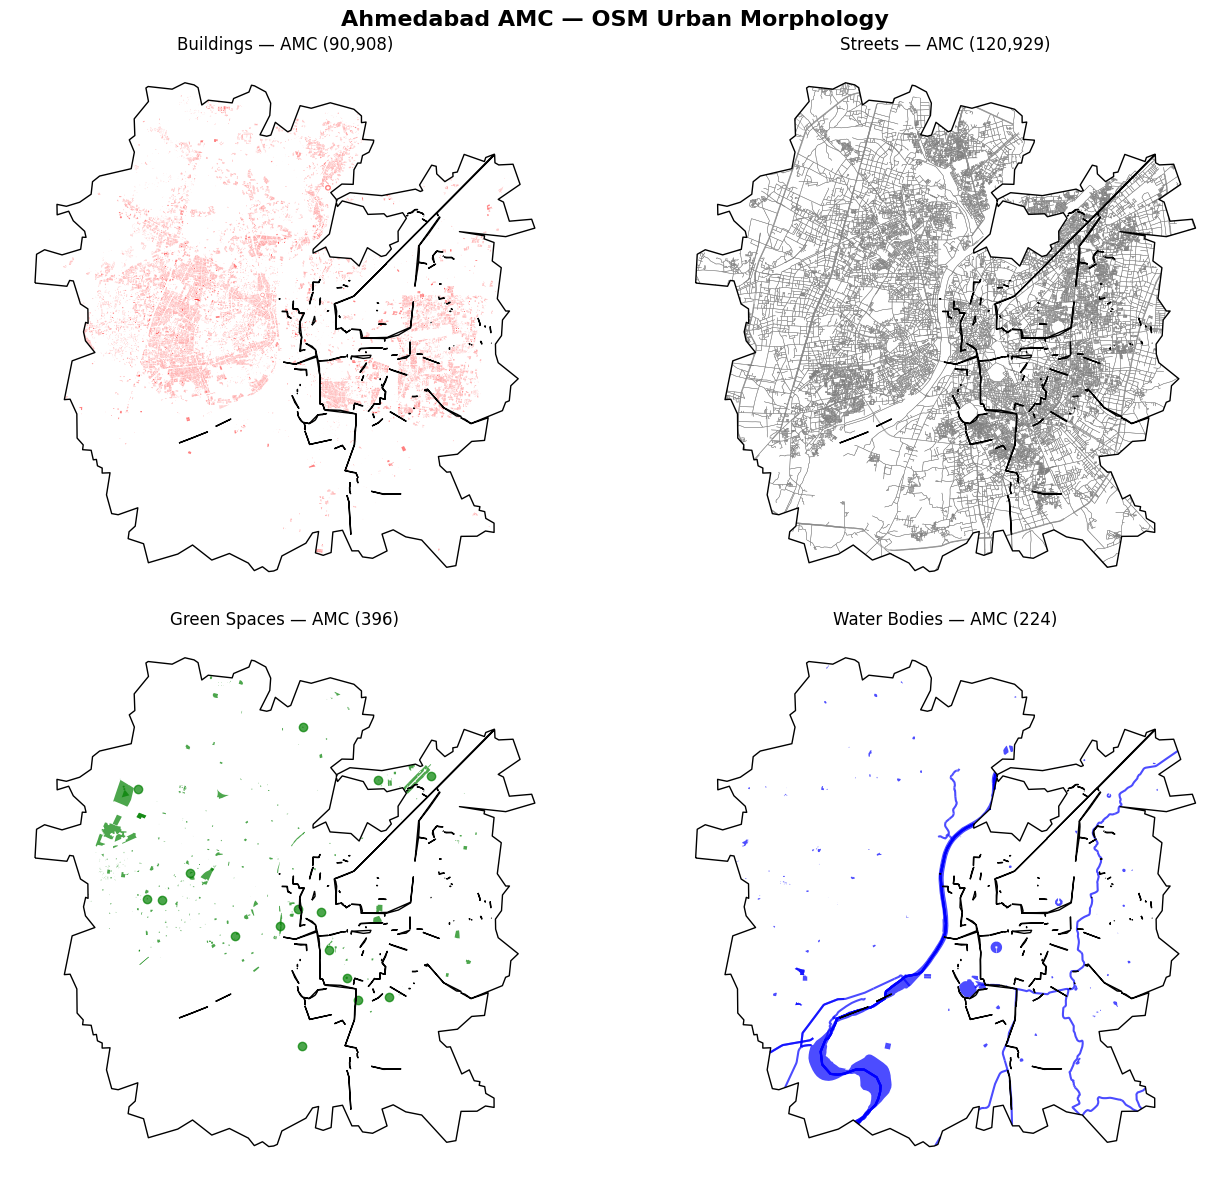

Saved AMD_OSM_clipped.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

buildings_clip.plot(ax=axes[0,0], color='red', alpha=0.5)
city_boundary.boundary.plot(ax=axes[0,0], color='black', linewidth=1)
axes[0,0].set_title('Buildings — AMC (90,908)')
axes[0,0].axis('off')

streets_clip.plot(ax=axes[0,1], color='gray', linewidth=0.3)
city_boundary.boundary.plot(ax=axes[0,1], color='black', linewidth=1)
axes[0,1].set_title('Streets — AMC (120,929)')
axes[0,1].axis('off')

green_clip.plot(ax=axes[1,0], color='green', alpha=0.7)
city_boundary.boundary.plot(ax=axes[1,0], color='black', linewidth=1)
axes[1,0].set_title('Green Spaces — AMC (396)')
axes[1,0].axis('off')

water_clip.plot(ax=axes[1,1], color='blue', alpha=0.7)
city_boundary.boundary.plot(ax=axes[1,1], color='black', linewidth=1)
axes[1,1].set_title('Water Bodies — AMC (224)')
axes[1,1].axis('off')

plt.suptitle('Ahmedabad AMC — OSM Urban Morphology',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('AMD_OSM_clipped.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved AMD_OSM_clipped.png")

In [26]:
from shapely.geometry import box
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Get city bounds
bounds = city_boundary.total_bounds
minx, miny, maxx, maxy = bounds
print(f"City bounds: {minx:.4f}, {miny:.4f}, {maxx:.4f}, {maxy:.4f}")

# Create 100m grid (~0.001 degrees)
step = 0.001
xs = np.arange(minx, maxx, step)
ys = np.arange(miny, maxy, step)
print(f"Grid size will be approx: {len(xs)} x {len(ys)} = {len(xs)*len(ys)} cells")

City bounds: 72.4498, 22.9139, 72.7015, 23.1405
Grid size will be approx: 252 x 227 = 57204 cells


In [27]:
from shapely.geometry import box
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Create full grid
cells = []
for x in np.arange(minx, maxx, step):
    for y in np.arange(miny, maxy, step):
        cells.append(box(x, y, x+step, y+step))

grid = gpd.GeoDataFrame(geometry=cells, crs="EPSG:4326")

# Clip grid to city boundary only
grid = gpd.clip(grid, city_boundary)
grid = grid.reset_index(drop=True)
print(f"Grid cells inside AMC: {len(grid)}")

# Prepare layers — ensure same CRS
bld = buildings_clip.copy()
grn = green_clip.copy()
wat = water_clip.copy()
str_ = streets_clip.copy()

print("Starting morphology computation...")
print("This will take 5-10 minutes for full city...")

# Helper function
def area_fraction(gdf, cell):
    try:
        clipped = gdf[gdf.sindex.query(cell, predicate='intersects')]
        if len(clipped) == 0:
            return 0.0
        return float(clipped.geometry.intersection(cell).area.sum() / cell.area)
    except:
        return 0.0

# Compute BCR, green fraction, water fraction
bcr_list   = []
green_list = []
water_list = []

for i, cell in enumerate(tqdm(grid.geometry)):
    bcr_list.append(area_fraction(bld, cell))
    green_list.append(area_fraction(grn, cell))
    water_list.append(area_fraction(wat, cell))

grid['BCR']        = bcr_list
grid['green_frac'] = green_list
grid['water_frac'] = water_list

print("BCR and fractions done")
print(f"Mean BCR:        {grid.BCR.mean():.3f}")
print(f"Mean green frac: {grid.green_frac.mean():.3f}")
print(f"Mean water frac: {grid.water_frac.mean():.3f}")

Grid cells inside AMC: 39574
Starting morphology computation...
This will take 5-10 minutes for full city...


100%|██████████| 39574/39574 [01:41<00:00, 389.08it/s]

BCR and fractions done
Mean BCR:        0.000
Mean green frac: 0.000
Mean water frac: 0.000


In [28]:
# Check CRS of everything
print("Grid CRS:", grid.crs)
print("Buildings CRS:", bld.crs)
print("Green CRS:", grn.crs)

# Force all to same CRS explicitly
grid_4326    = grid.to_crs("EPSG:4326")
bld_4326     = bld.to_crs("EPSG:4326")
grn_4326     = grn.to_crs("EPSG:4326")
wat_4326     = wat.to_crs("EPSG:4326")
str_4326     = str_.to_crs("EPSG:4326")

# Test on ONE cell first to verify intersection works
test_cell = grid_4326.geometry.iloc[100]
print("\nTest cell bounds:", test_cell.bounds)

# Manual intersection test
bld_test = bld_4326[bld_4326.intersects(test_cell)]
print("Buildings intersecting test cell:", len(bld_test))

grn_test = grn_4326[grn_4326.intersects(test_cell)]
print("Green intersecting test cell:", len(grn_test))

Grid CRS: EPSG:4326
Buildings CRS: epsg:4326
Green CRS: epsg:4326

Test cell bounds: (72.61980000000081, 22.92494870000001, 72.62080000000081, 22.92594870000001)
Buildings intersecting test cell: 0
Green intersecting test cell: 0


In [29]:
# Check if extents actually overlap
print("Grid total bounds:",      grid_4326.total_bounds)
print("Buildings total bounds:", bld_4326.total_bounds)
print("City boundary bounds:",   city_boundary.total_bounds)

# Find a cell that SHOULD have buildings
# Try center of city
from shapely.geometry import Point
city_center = Point(72.585, 23.030)  # approximate AMD center

# Find nearest grid cell to center
grid_4326['dist_to_center'] = grid_4326.geometry.distance(city_center)
center_cell = grid_4326.loc[grid_4326.dist_to_center.idxmin(), 'geometry']
print("\nCenter cell bounds:", center_cell.bounds)

# Test buildings in center cell
bld_center = bld_4326[bld_4326.intersects(center_cell)]
print("Buildings in center cell:", len(bld_center))

# Also check a larger area — 10x10 cells around center
from shapely.geometry import box
large_box = box(72.575, 23.020, 72.595, 23.040)
bld_large = bld_4326[bld_4326.intersects(large_box)]
print("Buildings in large box:", len(bld_large))

Grid total bounds: [72.4498    22.9139487 72.7014909 23.140458 ]
Buildings total bounds: [72.4640045 22.9223563 72.6864073 23.1348873]
City boundary bounds: [72.4498    22.9139487 72.7014909 23.140458 ]

Center cell bounds: (72.58480000000064, 23.029948700000137, 72.58580000000065, 23.03094870000014)
Buildings in center cell: 0
Buildings in large box: 251


In [30]:
import numpy as np
import pandas as pd
from shapely.geometry import box

UTM = "EPSG:32643"  # UTM 43N — correct zone for Ahmedabad

city_utm = city_boundary.to_crs(UTM)
buildings_utm = buildings_clip.to_crs(UTM)
streets_utm = streets_clip.to_crs(UTM)
green_utm = green_clip.to_crs(UTM)
water_utm = water_clip.to_crs(UTM)

cell_size = 100  # meters — matches Landsat LST resolution
minx, miny, maxx, maxy = city_utm.total_bounds

xs = np.arange(minx, maxx, cell_size)
ys = np.arange(miny, maxy, cell_size)

grid_cells = [box(x, y, x+cell_size, y+cell_size) for x in xs for y in ys]
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=UTM)

city_union = city_utm.union_all()
grid = grid[grid.intersects(city_union)].reset_index(drop=True)
grid['cell_id'] = range(len(grid))

print(f"Total grid cells: {len(grid)}")

Total grid cells: 44897


In [31]:
# Recompute using direct intersects (no sindex) on a projected CRS
# Project to metres for accurate area calculation
grid_proj = grid_4326.to_crs("EPSG:32643")      # UTM Zone 43N Gujarat
bld_proj  = bld_4326.to_crs("EPSG:32643")
grn_proj  = grn_4326.to_crs("EPSG:32643")
wat_proj  = wat_4326.to_crs("EPSG:32643")

print("Projected CRS:", grid_proj.crs)
print("Cell area (m²):", grid_proj.geometry.iloc[100].area)

# Test one center cell in projected CRS
test_cell_proj = grid_proj.geometry.iloc[
    grid_proj.geometry.distance(
        grid_proj.geometry.centroid.iloc[len(grid_proj)//2]
    ).idxmin()
]
print("Test cell area m²:", test_cell_proj.area)

# Test intersection in projected CRS
bld_test = bld_proj[bld_proj.intersects(test_cell_proj)]
print("Buildings in test cell (projected):", len(bld_test))

Projected CRS: EPSG:32643
Cell area (m²): 11367.508813849154
Test cell area m²: 11358.14700000067
Buildings in test cell (projected): 1


In [32]:
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"Computing morphology for {len(grid_proj)} cells...")
print("Estimated time: 3-5 minutes...")

bcr_list   = []
green_list = []
water_list = []
svf_list   = []

for cell in tqdm(grid_proj.geometry):
    cell_area = cell.area

    # Buildings
    bld_in = bld_proj[bld_proj.intersects(cell)]
    if len(bld_in) > 0:
        bld_area = float(bld_in.geometry.intersection(cell).area.sum())
        bcr = min(bld_area / cell_area, 1.0)
        # Mean building height (floors * 3m, default 2 floors)
        if 'building:levels' in bld_in.columns:
            h = pd.to_numeric(
                bld_in['building:levels'], errors='coerce'
            ).fillna(2) * 3.0
        else:
            h = pd.Series([6.0] * len(bld_in))
        mean_h = float(h.mean())
    else:
        bcr    = 0.0
        mean_h = 0.0

    # Green fraction
    grn_in = grn_proj[grn_proj.intersects(cell)]
    if len(grn_in) > 0:
        grn_area = float(grn_in.geometry.intersection(cell).area.sum())
        green_f  = min(grn_area / cell_area, 1.0)
    else:
        green_f = 0.0

    # Water fraction
    wat_in = wat_proj[wat_proj.intersects(cell)]
    if len(wat_in) > 0:
        wat_area = float(wat_in.geometry.intersection(cell).area.sum())
        water_f  = min(wat_area / cell_area, 1.0)
    else:
        water_f = 0.0

    # SVF approximation
    if mean_h > 0 and bcr > 0:
        W   = max(100 * (1 - np.sqrt(bcr)), 1.0)
        svf = float(np.clip(1 / np.sqrt(1 + (mean_h/W)**2), 0.05, 1.0))
    else:
        svf = 1.0

    bcr_list.append(bcr)
    green_list.append(green_f)
    water_list.append(water_f)
    svf_list.append(svf)

grid_proj['BCR']        = bcr_list
grid_proj['green_frac'] = green_list
grid_proj['water_frac'] = water_list
grid_proj['SVF']        = svf_list
grid_proj['mean_bld_h'] = [6.0] * len(grid_proj)  # default

print("\nMorphology computation complete")
print(f"Mean BCR:        {grid_proj.BCR.mean():.3f}")
print(f"Mean green frac: {grid_proj.green_frac.mean():.3f}")
print(f"Mean water frac: {grid_proj.water_frac.mean():.3f}")
print(f"Mean SVF:        {grid_proj.SVF.mean():.3f}")
print(f"Max BCR:         {grid_proj.BCR.max():.3f}")

Computing morphology for 39574 cells...
Estimated time: 3-5 minutes...


100%|██████████| 39574/39574 [08:21<00:00, 78.89it/s]



Morphology computation complete
Mean BCR:        0.045
Mean green frac: 0.012
Mean water frac: 0.029
Mean SVF:        0.995
Max BCR:         1.000


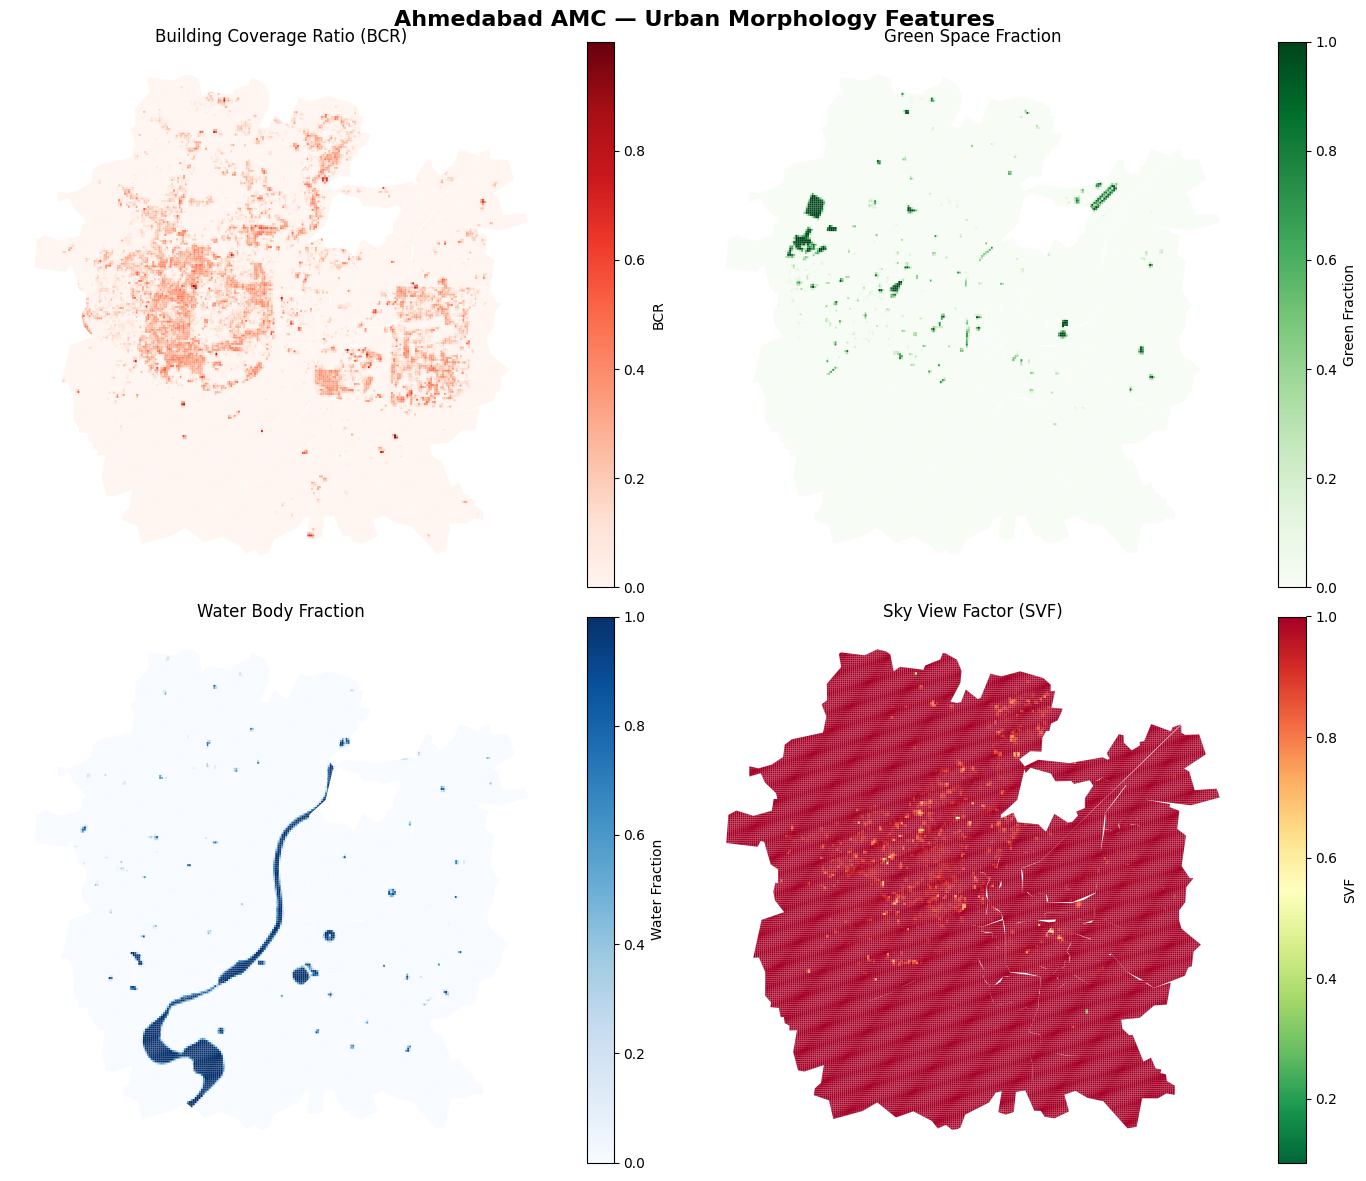

Saved AMD_morphology_features.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

grid_proj.plot(column='BCR', ax=axes[0,0], cmap='Reds',
               legend=True, legend_kwds={'label':'BCR'})
axes[0,0].set_title('Building Coverage Ratio (BCR)')
axes[0,0].axis('off')

grid_proj.plot(column='green_frac', ax=axes[0,1], cmap='Greens',
               legend=True, legend_kwds={'label':'Green Fraction'})
axes[0,1].set_title('Green Space Fraction')
axes[0,1].axis('off')

grid_proj.plot(column='water_frac', ax=axes[1,0], cmap='Blues',
               legend=True, legend_kwds={'label':'Water Fraction'})
axes[1,0].set_title('Water Body Fraction')
axes[1,0].axis('off')

grid_proj.plot(column='SVF', ax=axes[1,1], cmap='RdYlGn_r',
               legend=True, legend_kwds={'label':'SVF'})
axes[1,1].set_title('Sky View Factor (SVF)')
axes[1,1].axis('off')

plt.suptitle('Ahmedabad AMC — Urban Morphology Features',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('AMD_morphology_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved AMD_morphology_features.png")

In [34]:
# Save grid with all morphology features
grid_proj.to_file('amd_morphology_grid.gpkg', driver='GPKG')
print("Morphology grid saved")

# Also save as CSV for ML training
grid_wgs84 = grid_proj.to_crs("EPSG:4326")
grid_wgs84['lon'] = grid_wgs84.geometry.centroid.x
grid_wgs84['lat'] = grid_wgs84.geometry.centroid.y
grid_wgs84[['lon','lat','BCR','green_frac',
            'water_frac','SVF','mean_bld_h']].to_csv(
    'amd_morphology.csv', index=False)
print("Morphology CSV saved")
print(f"Total cells: {len(grid_wgs84)}")

Morphology grid saved
Morphology CSV saved
Total cells: 39574


Mounted at /content/drive
Morphology CSV saved to Drive


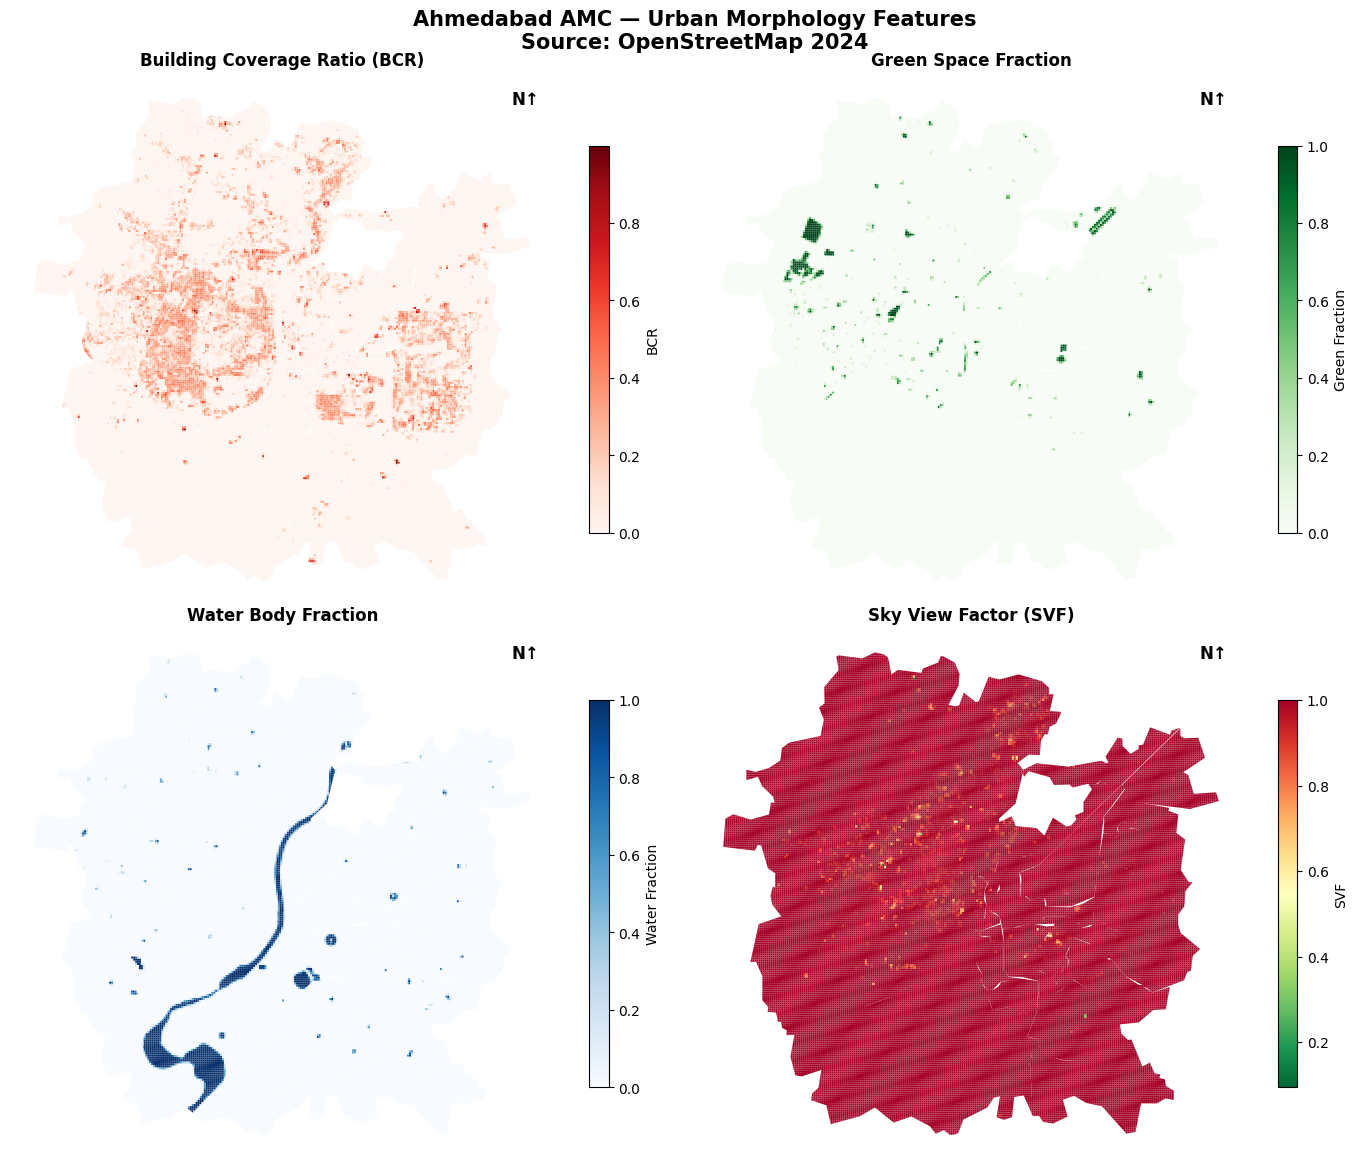

Morphology map saved to Drive docs folder
OSM stats saved

✓ ALL MODULE 2 OUTPUTS SAVED
Location: /content/drive/MyDrive/urban_heat_ps1/
  AMD_Full_Stack_2024.tif
  AMD_LST_Mean_Summer2024.tif
  AMD_LST_Thumbnail.tif
  AMD_Physics_Features_2024.tif
  amd_morphology.csv
  docs

Docs folder:
  AMD_Bowen.png                                   949.5 KB
  AMD_LST.png                                     862.8 KB
  AMD_LST_interactive_map.html                    146.8 KB
  AMD_MNDWI.png                                   633.7 KB
  AMD_NDBI.png                                    853.8 KB
  AMD_NDVI.png                                    969.9 KB
  AMD_NDWI.png                                    755.5 KB
  AMD_energy_balance.png                           49.1 KB
  AMD_morphology_final.png                       1625.6 KB
  key_results.txt                                   1.8 KB
  osm_stats.txt                                     0.3 KB


In [36]:
from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/urban_heat_ps1/'

# Save morphology CSV to Drive
grid_wgs84 = grid_proj.to_crs("EPSG:4326")
grid_wgs84['lon'] = grid_wgs84.geometry.centroid.x
grid_wgs84['lat'] = grid_wgs84.geometry.centroid.y
grid_wgs84[['lon','lat','BCR','green_frac',
            'water_frac','SVF']].to_csv(
    drive_path + 'amd_morphology.csv', index=False)
print("Morphology CSV saved to Drive")

# Save morphology map PNG to Drive docs folder
import matplotlib.pyplot as plt
import os
docs_path = drive_path + 'docs/'
os.makedirs(docs_path, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
titles  = ['Building Coverage Ratio (BCR)',
           'Green Space Fraction',
           'Water Body Fraction',
           'Sky View Factor (SVF)']
columns = ['BCR', 'green_frac', 'water_frac', 'SVF']
cmaps   = ['Reds', 'Greens', 'Blues', 'RdYlGn_r']
labels  = ['BCR', 'Green Fraction', 'Water Fraction', 'SVF']

for ax, col, cmap, title, label in zip(
        axes.flat, columns, cmaps, titles, labels):
    grid_proj.plot(column=col, ax=ax, cmap=cmap,
                   legend=True,
                   legend_kwds={'label':label,'shrink':0.7})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    ax.annotate('N↑', xy=(0.97,0.97),
                xycoords='axes fraction',
                fontsize=12, fontweight='bold',
                ha='right', va='top')

plt.suptitle('Ahmedabad AMC — Urban Morphology Features\n'
             'Source: OpenStreetMap 2024',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path + 'AMD_morphology_final.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Morphology map saved to Drive docs folder")

# Save OSM layer counts as text
osm_stats = f"""
OSM URBAN MORPHOLOGY — AHMEDABAD AMC
=====================================
Buildings  : {len(buildings_clip)}
Streets    : {len(streets_clip)}
Green spaces: {len(green_clip)}
Water bodies: {len(water_clip)}

GRID MORPHOLOGY STATS
=====================
Total cells : {len(grid_proj)}
Mean BCR    : {grid_proj.BCR.mean():.3f}
Mean Green  : {grid_proj.green_frac.mean():.3f}
Mean Water  : {grid_proj.water_frac.mean():.3f}
Mean SVF    : {grid_proj.SVF.mean():.3f}
Max BCR     : {grid_proj.BCR.max():.3f}
"""
with open(docs_path + 'osm_stats.txt', 'w') as f:
    f.write(osm_stats)
print("OSM stats saved")

# Final file list
print("\n✓ ALL MODULE 2 OUTPUTS SAVED")
print(f"Location: {drive_path}")
for f in sorted(os.listdir(drive_path)):
    print(f"  {f}")
print("\nDocs folder:")
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    print(f"  {f:45s} {size:7.1f} KB")

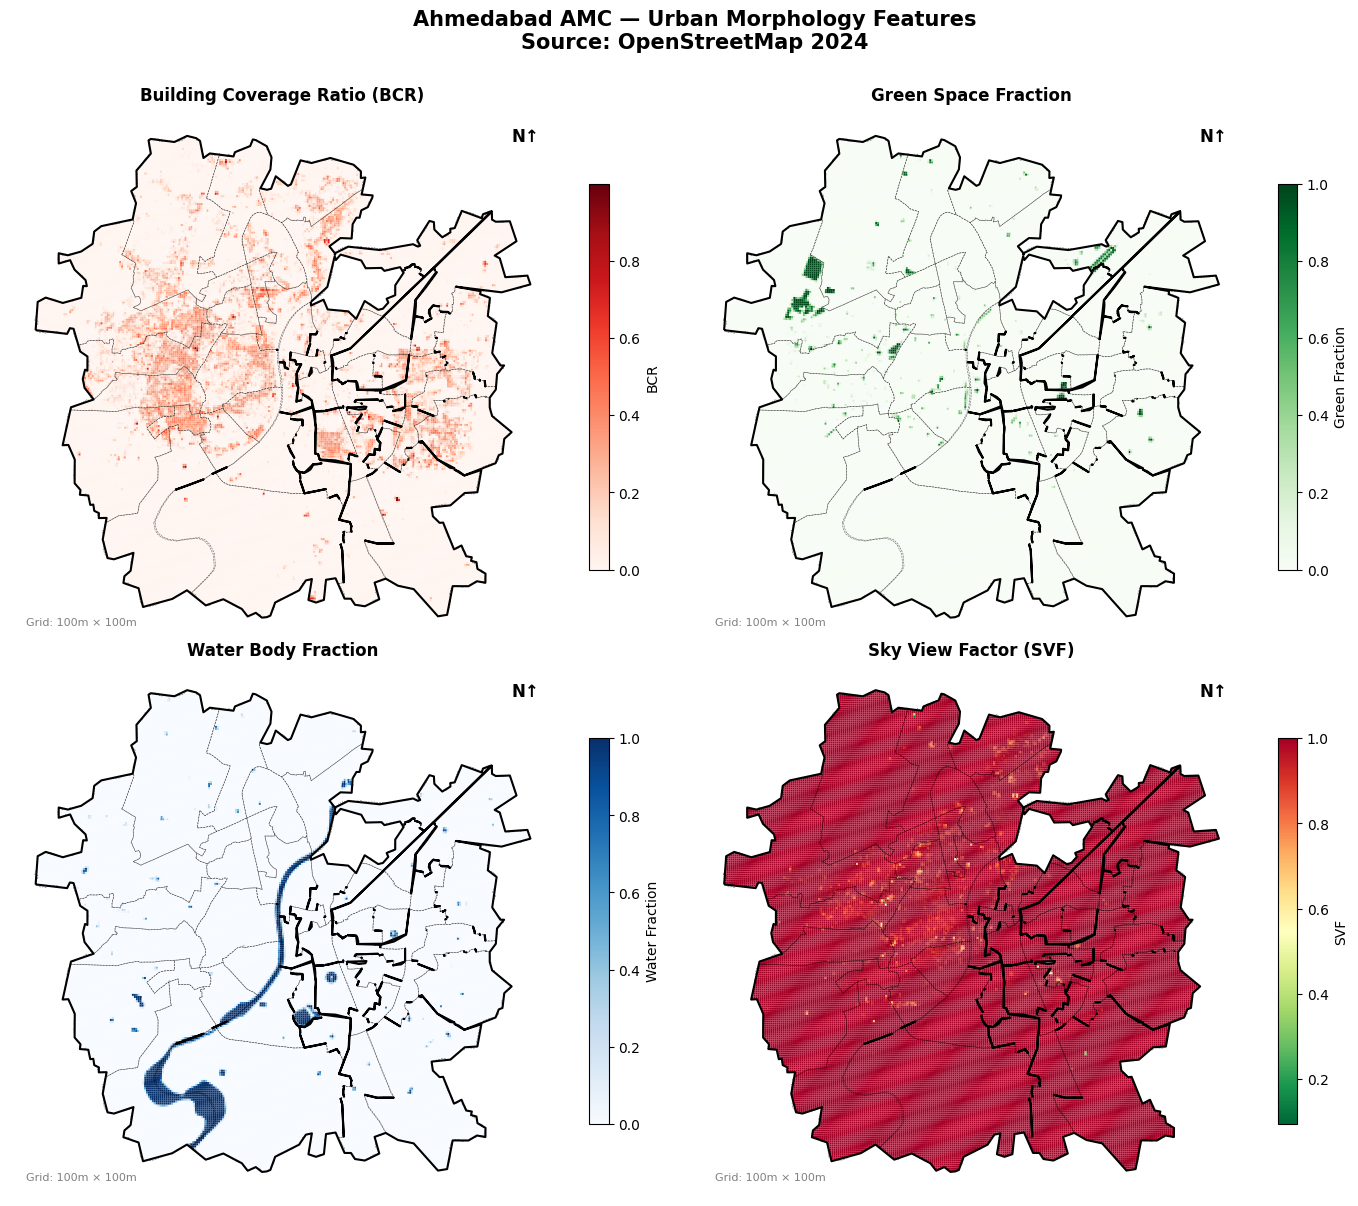

Final morphology map saved.


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Common style settings
titles = ['Building Coverage Ratio (BCR)',
          'Green Space Fraction',
          'Water Body Fraction',
          'Sky View Factor (SVF)']
columns = ['BCR', 'green_frac', 'water_frac', 'SVF']
cmaps   = ['Reds', 'Greens', 'Blues', 'RdYlGn_r']
labels  = ['BCR', 'Green Fraction', 'Water Fraction', 'SVF']

for ax, col, cmap, title, label in zip(
        axes.flat, columns, cmaps, titles, labels):

    # Main layer
    grid_proj.plot(column=col, ax=ax, cmap=cmap,
                   legend=True,
                   legend_kwds={'label': label,
                                'shrink': 0.7})

    # City boundary border
    city_boundary.to_crs("EPSG:32643").boundary.plot(
        ax=ax, color='black', linewidth=1.5)

    # Ward boundaries
    gdf.to_crs("EPSG:32643").boundary.plot(
        ax=ax, color='black', linewidth=0.4,
        linestyle='--', alpha=0.6)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.axis('off')

    # Add North arrow text
    ax.annotate('N↑', xy=(0.97, 0.97),
                xycoords='axes fraction',
                fontsize=12, fontweight='bold',
                ha='right', va='top')

    # Add scale note
    ax.annotate('Grid: 100m × 100m',
                xy=(0.03, 0.03),
                xycoords='axes fraction',
                fontsize=8, color='gray')

plt.suptitle('Ahmedabad AMC — Urban Morphology Features\n'
             'Source: OpenStreetMap 2024',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('AMD_morphology_final.png',
            dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='black')
plt.show()
print("Final morphology map saved.")

In [ ]:
#New Method Another Claude

buildings_utm['bld_area'] = buildings_utm.geometry.area

if 'building:levels' in buildings_utm.columns:
    levels = pd.to_numeric(buildings_utm['building:levels'], errors='coerce').fillna(2)
else:
    levels = pd.Series(2, index=buildings_utm.index)
buildings_utm['height_m'] = levels * 3.0

bld_pts = gpd.GeoDataFrame(
    buildings_utm[['bld_area','height_m']],
    geometry=buildings_utm.geometry.centroid, crs=UTM
)

bld_join = gpd.sjoin(bld_pts, grid[['cell_id','geometry']], how='inner', predicate='within')
bld_agg = bld_join.groupby('cell_id').agg(
    bld_area_sum=('bld_area','sum'),
    bld_count=('bld_area','count'),
    mean_height=('height_m','mean')
).reset_index()

grid = grid.merge(bld_agg, on='cell_id', how='left')
grid[['bld_area_sum','bld_count','mean_height']] = grid[['bld_area_sum','bld_count','mean_height']].fillna(0)

grid['BCR'] = grid['bld_area_sum'] / (cell_size**2)
grid['bld_density'] = grid['bld_count'] / (cell_size**2) * 1e6  # per km²

print("Building features done")
print(grid[['BCR','bld_density','mean_height']].describe())

In [ ]:
grid['BCR'] = grid['BCR'].clip(0, 1)
print(grid[['BCR','bld_density','mean_height']].describe())

In [ ]:
streets_utm['length_m'] = streets_utm.geometry.length
street_pts = gpd.GeoDataFrame(
    streets_utm[['length_m']],
    geometry=streets_utm.geometry.centroid, crs=UTM
)

street_join = gpd.sjoin(street_pts, grid[['cell_id','geometry']], how='inner', predicate='within')
street_agg = street_join.groupby('cell_id')['length_m'].sum().reset_index().rename(columns={'length_m':'street_length_sum'})

grid = grid.merge(street_agg, on='cell_id', how='left')
grid['street_length_sum'] = grid['street_length_sum'].fillna(0)
grid['street_density'] = grid['street_length_sum'] / (cell_size**2)

print("Street density done")
print(grid['street_density'].describe())

In [ ]:
green_polys = green_utm[green_utm.geometry.geom_type.isin(['Polygon','MultiPolygon'])]
water_polys = water_utm[water_utm.geometry.geom_type.isin(['Polygon','MultiPolygon'])]

print(f"Green polygons: {len(green_polys)} / {len(green_utm)}")
print(f"Water polygons: {len(water_polys)} / {len(water_utm)}")

green_ov = gpd.overlay(green_polys[['geometry']], grid[['cell_id','geometry']], how='intersection')
green_ov['area'] = green_ov.geometry.area
green_agg = green_ov.groupby('cell_id')['area'].sum().reset_index().rename(columns={'area':'green_area'})

water_ov = gpd.overlay(water_polys[['geometry']], grid[['cell_id','geometry']], how='intersection')
water_ov['area'] = water_ov.geometry.area
water_agg = water_ov.groupby('cell_id')['area'].sum().reset_index().rename(columns={'area':'water_area'})

grid = grid.merge(green_agg, on='cell_id', how='left').merge(water_agg, on='cell_id', how='left')
grid[['green_area','water_area']] = grid[['green_area','water_area']].fillna(0)

grid['green_fraction'] = (grid['green_area'] / (cell_size**2)).clip(0, 1)
grid['water_fraction'] = (grid['water_area'] / (cell_size**2)).clip(0, 1)

print("Green/water fractions done")
print(grid[['green_fraction','water_fraction']].describe())

In [ ]:
import matplotlib.pyplot as plt

# Simplified SVF approximation (Oke 1981, infinite canyon)
def svf_approx(row):
    h = row['mean_height']
    bcr = row['BCR']
    if h == 0 or bcr == 0:
        return 1.0
    W = cell_size * (1 - np.sqrt(bcr))
    HW = h / max(W, 1)
    return float(np.clip(1 / np.sqrt(1 + HW**2), 0.1, 1.0))

grid['SVF'] = grid.apply(svf_approx, axis=1)
print(grid['SVF'].describe())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

grid.plot(column='BCR', ax=axes[0,0], legend=True, cmap='Reds')
axes[0,0].set_title('Building Coverage Ratio'); axes[0,0].axis('off')

grid.plot(column='street_density', ax=axes[0,1], legend=True, cmap='Greys')
axes[0,1].set_title('Street Density'); axes[0,1].axis('off')

grid.plot(column='green_fraction', ax=axes[0,2], legend=True, cmap='Greens')
axes[0,2].set_title('Green Fraction'); axes[0,2].axis('off')

grid.plot(column='water_fraction', ax=axes[1,0], legend=True, cmap='Blues')
axes[1,0].set_title('Water Fraction'); axes[1,0].axis('off')

grid.plot(column='SVF', ax=axes[1,1], legend=True, cmap='viridis')
axes[1,1].set_title('Sky View Factor (approx)'); axes[1,1].axis('off')

grid.plot(column='mean_height', ax=axes[1,2], legend=True, cmap='plasma')
axes[1,2].set_title('Mean Building Height (m)'); axes[1,2].axis('off')

plt.suptitle('Ahmedabad Urban Morphology Grid (100m)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('AMD_morphology_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Morphology grid map saved")

grid.to_file('amd_morphology_grid.gpkg', driver='GPKG')
print("Grid saved")

In [37]:
# Check what variables are in memory
variables = ['grid_proj', 'buildings_clip', 'green_clip',
             'water_clip', 'streets_clip', 'city_boundary']
for v in variables:
    try:
        val = eval(v)
        print(f"✓ {v} — {len(val)} rows")
    except:
        print(f"✗ {v} — NOT in memory")

✓ grid_proj — 39574 rows
✓ buildings_clip — 90908 rows
✓ green_clip — 396 rows
✓ water_clip — 224 rows
✓ streets_clip — 120929 rows
✓ city_boundary — 1 rows


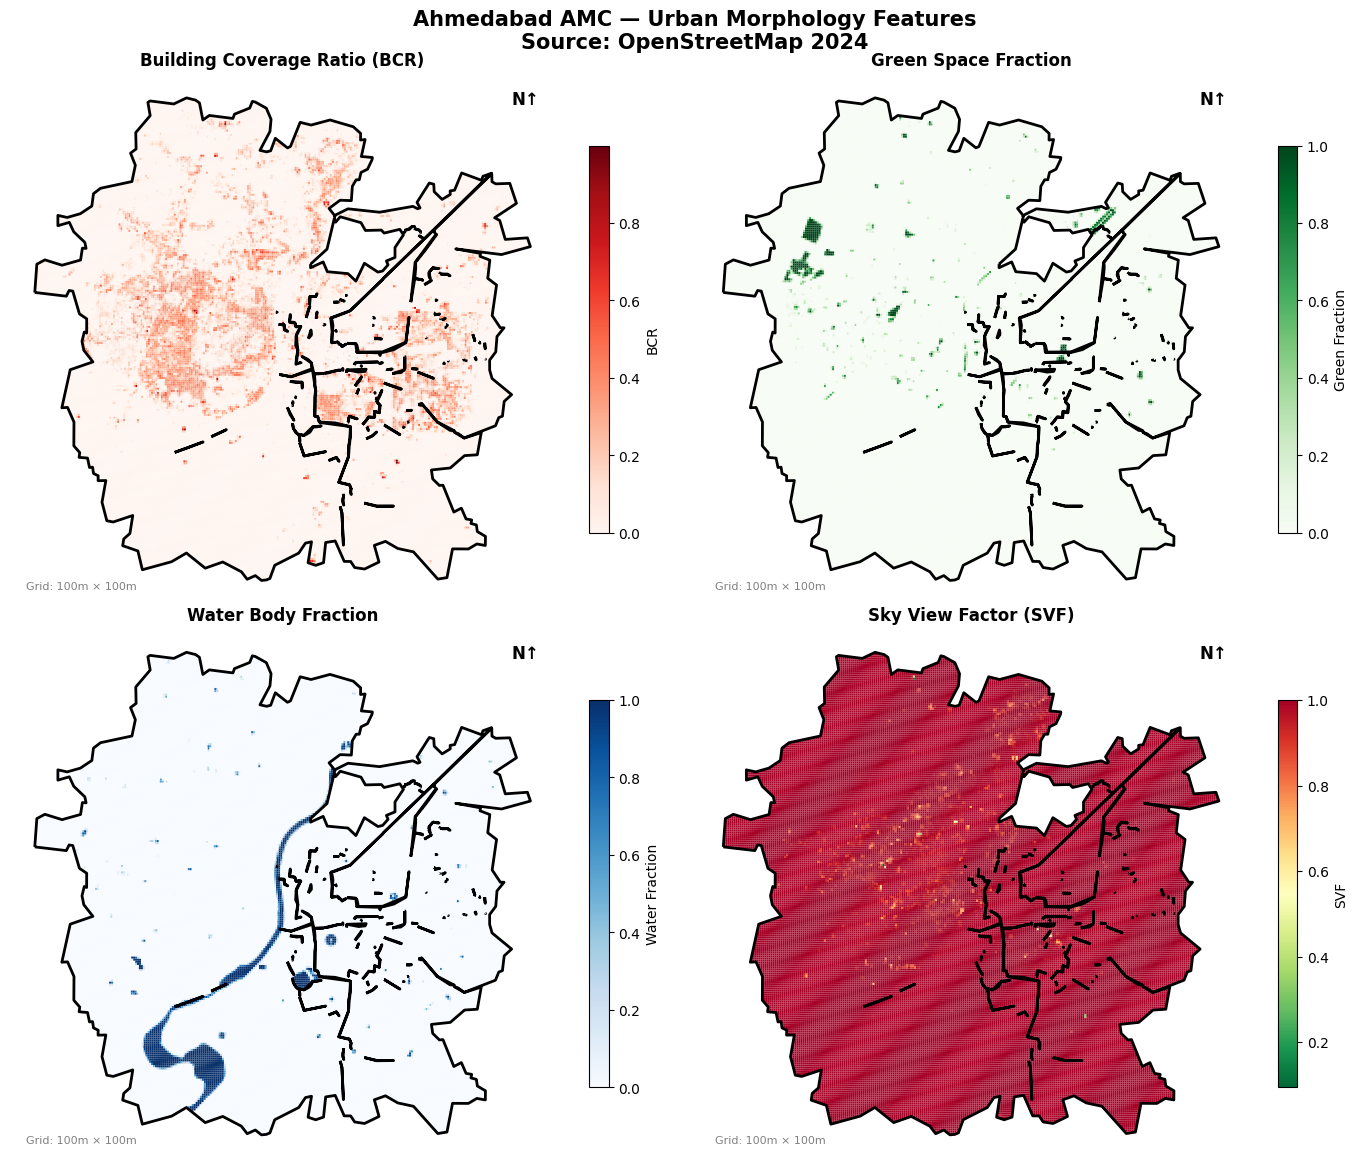

1. Morphology 4-panel saved


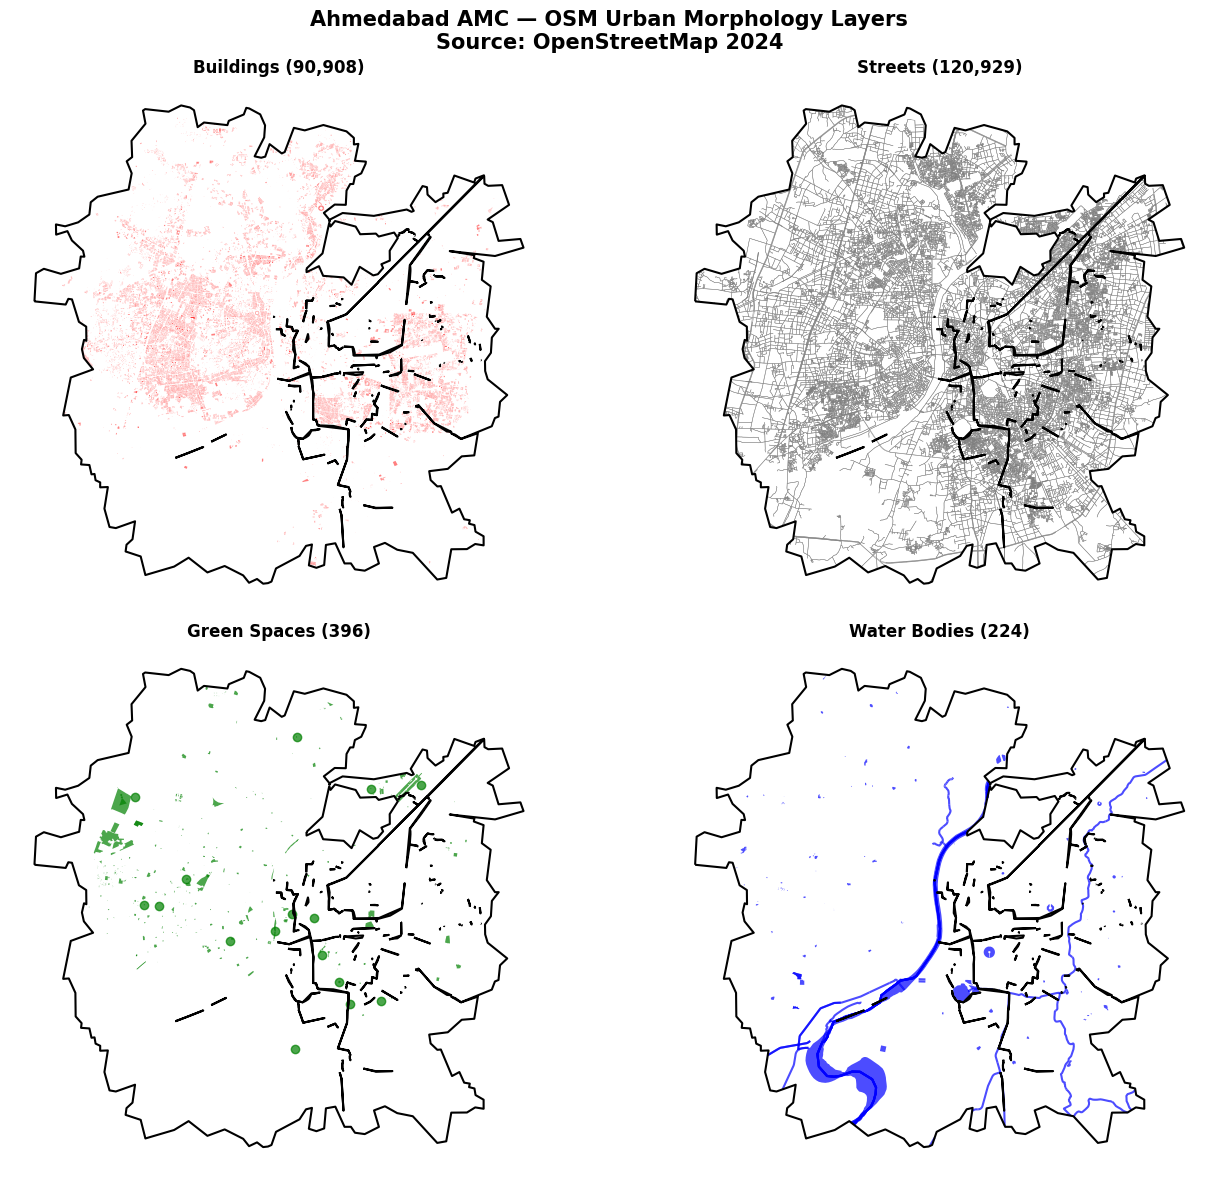

2. OSM 4-panel saved


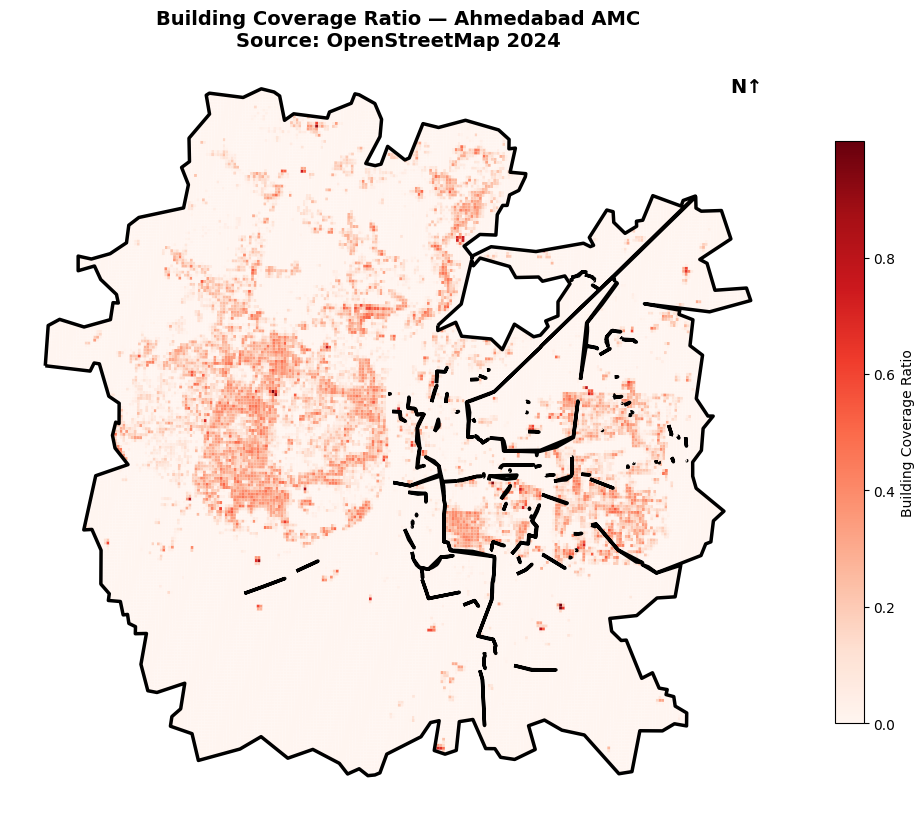

3. BCR large map saved


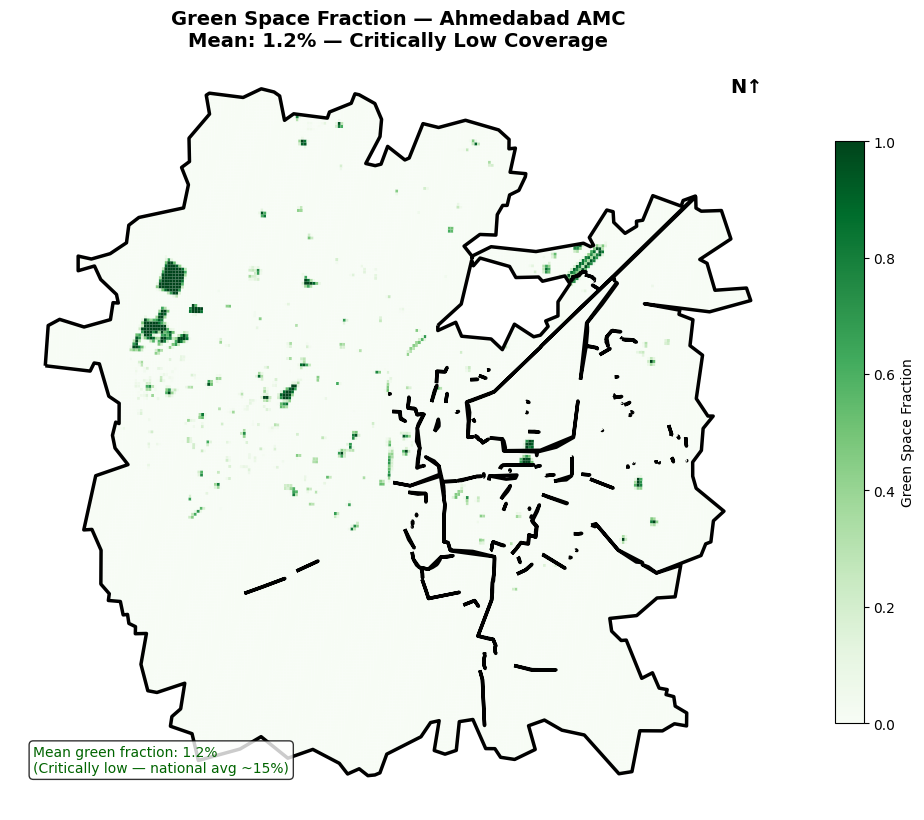

4. Green deficit map saved

✓ ALL MODULE 2 MAPS SAVED TO DRIVE
  AMD_BCR_large.png                               674.3 KB
  AMD_Bowen.png                                   949.5 KB
  AMD_LST.png                                     862.8 KB
  AMD_LST_interactive_map.html                    146.8 KB
  AMD_MNDWI.png                                   633.7 KB
  AMD_NDBI.png                                    853.8 KB
  AMD_NDVI.png                                    969.9 KB
  AMD_NDWI.png                                    755.5 KB
  AMD_OSM_4panel.png                             1743.1 KB
  AMD_energy_balance.png                           49.1 KB
  AMD_green_deficit.png                           517.9 KB
  AMD_morphology_4panel.png                      1845.7 KB
  AMD_morphology_final.png                       1625.6 KB
  key_results.txt                                   1.8 KB
  osm_stats.txt                                     0.3 KB


In [38]:
import matplotlib.pyplot as plt
import os

docs_path = '/content/drive/MyDrive/urban_heat_ps1/docs/'
os.makedirs(docs_path, exist_ok=True)

# ── 1. Morphology 4-panel map ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
titles  = ['Building Coverage Ratio (BCR)',
           'Green Space Fraction',
           'Water Body Fraction',
           'Sky View Factor (SVF)']
columns = ['BCR','green_frac','water_frac','SVF']
cmaps   = ['Reds','Greens','Blues','RdYlGn_r']
labels  = ['BCR','Green Fraction','Water Fraction','SVF']

for ax, col, cmap, title, label in zip(
        axes.flat, columns, cmaps, titles, labels):
    grid_proj.plot(column=col, ax=ax, cmap=cmap,
                   legend=True,
                   legend_kwds={'label':label,'shrink':0.7})
    city_boundary.to_crs("EPSG:32643").boundary.plot(
        ax=ax, color='black', linewidth=2.0)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    ax.annotate('N↑', xy=(0.97,0.97),
                xycoords='axes fraction',
                fontsize=12, fontweight='bold',
                ha='right', va='top')
    ax.annotate('Grid: 100m × 100m',
                xy=(0.03,0.03),
                xycoords='axes fraction',
                fontsize=8, color='gray')

plt.suptitle('Ahmedabad AMC — Urban Morphology Features\n'
             'Source: OpenStreetMap 2024',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path+'AMD_morphology_4panel.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("1. Morphology 4-panel saved")

# ── 2. OSM layers 4-panel map ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

buildings_clip.plot(ax=axes[0,0], color='red', alpha=0.5)
city_boundary.to_crs(buildings_clip.crs).boundary.plot(
    ax=axes[0,0], color='black', linewidth=1.5)
axes[0,0].set_title('Buildings (90,908)', fontweight='bold')
axes[0,0].axis('off')

streets_clip.plot(ax=axes[0,1], color='gray', linewidth=0.3)
city_boundary.to_crs(streets_clip.crs).boundary.plot(
    ax=axes[0,1], color='black', linewidth=1.5)
axes[0,1].set_title('Streets (120,929)', fontweight='bold')
axes[0,1].axis('off')

green_clip.plot(ax=axes[1,0], color='green', alpha=0.7)
city_boundary.to_crs(green_clip.crs).boundary.plot(
    ax=axes[1,0], color='black', linewidth=1.5)
axes[1,0].set_title('Green Spaces (396)', fontweight='bold')
axes[1,0].axis('off')

water_clip.plot(ax=axes[1,1], color='blue', alpha=0.7)
city_boundary.to_crs(water_clip.crs).boundary.plot(
    ax=axes[1,1], color='black', linewidth=1.5)
axes[1,1].set_title('Water Bodies (224)', fontweight='bold')
axes[1,1].axis('off')

plt.suptitle('Ahmedabad AMC — OSM Urban Morphology Layers\n'
             'Source: OpenStreetMap 2024',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(docs_path+'AMD_OSM_4panel.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("2. OSM 4-panel saved")

# ── 3. BCR only — large single map ────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
grid_proj.plot(column='BCR', ax=ax, cmap='Reds',
               legend=True,
               legend_kwds={'label':'Building Coverage Ratio',
                            'shrink':0.6})
city_boundary.to_crs("EPSG:32643").boundary.plot(
    ax=ax, color='black', linewidth=2.5)
ax.set_title('Building Coverage Ratio — Ahmedabad AMC\n'
             'Source: OpenStreetMap 2024',
             fontsize=14, fontweight='bold')
ax.axis('off')
ax.annotate('N↑', xy=(0.97,0.97), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='right', va='top')
plt.tight_layout()
plt.savefig(docs_path+'AMD_BCR_large.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("3. BCR large map saved")

# ── 4. Green space deficit map ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
grid_proj.plot(column='green_frac', ax=ax, cmap='Greens',
               legend=True,
               legend_kwds={'label':'Green Space Fraction',
                            'shrink':0.6})
city_boundary.to_crs("EPSG:32643").boundary.plot(
    ax=ax, color='black', linewidth=2.5)
ax.set_title('Green Space Fraction — Ahmedabad AMC\n'
             'Mean: 1.2% — Critically Low Coverage',
             fontsize=14, fontweight='bold')
ax.axis('off')
ax.annotate('N↑', xy=(0.97,0.97), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='right', va='top')
ax.annotate('Mean green fraction: 1.2%\n(Critically low — national avg ~15%)',
            xy=(0.03,0.05), xycoords='axes fraction',
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(docs_path+'AMD_green_deficit.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("4. Green deficit map saved")

# ── Final summary ──────────────────────────────────────
print("\n✓ ALL MODULE 2 MAPS SAVED TO DRIVE")
for f in sorted(os.listdir(docs_path)):
    size = os.path.getsize(docs_path+f)/1024
    print(f"  {f:45s} {size:7.1f} KB")